In [1]:
import pandas as pd

df = pd.read_csv('/content/data.csv', encoding='latin1')
print(df.columns)
df.head()

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='object')


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [2]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Revenue'] = df['Quantity'] * df['Unit_Price']
df = df.set_index('Order_Date')

weekly = df['Revenue'].resample('W').sum()

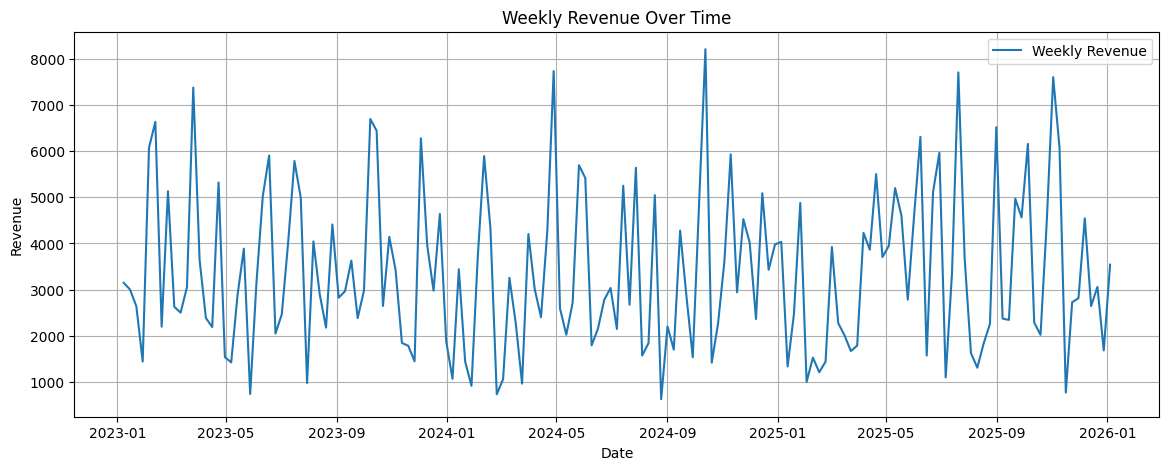

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(weekly, label='Weekly Revenue')
plt.title('Weekly Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()

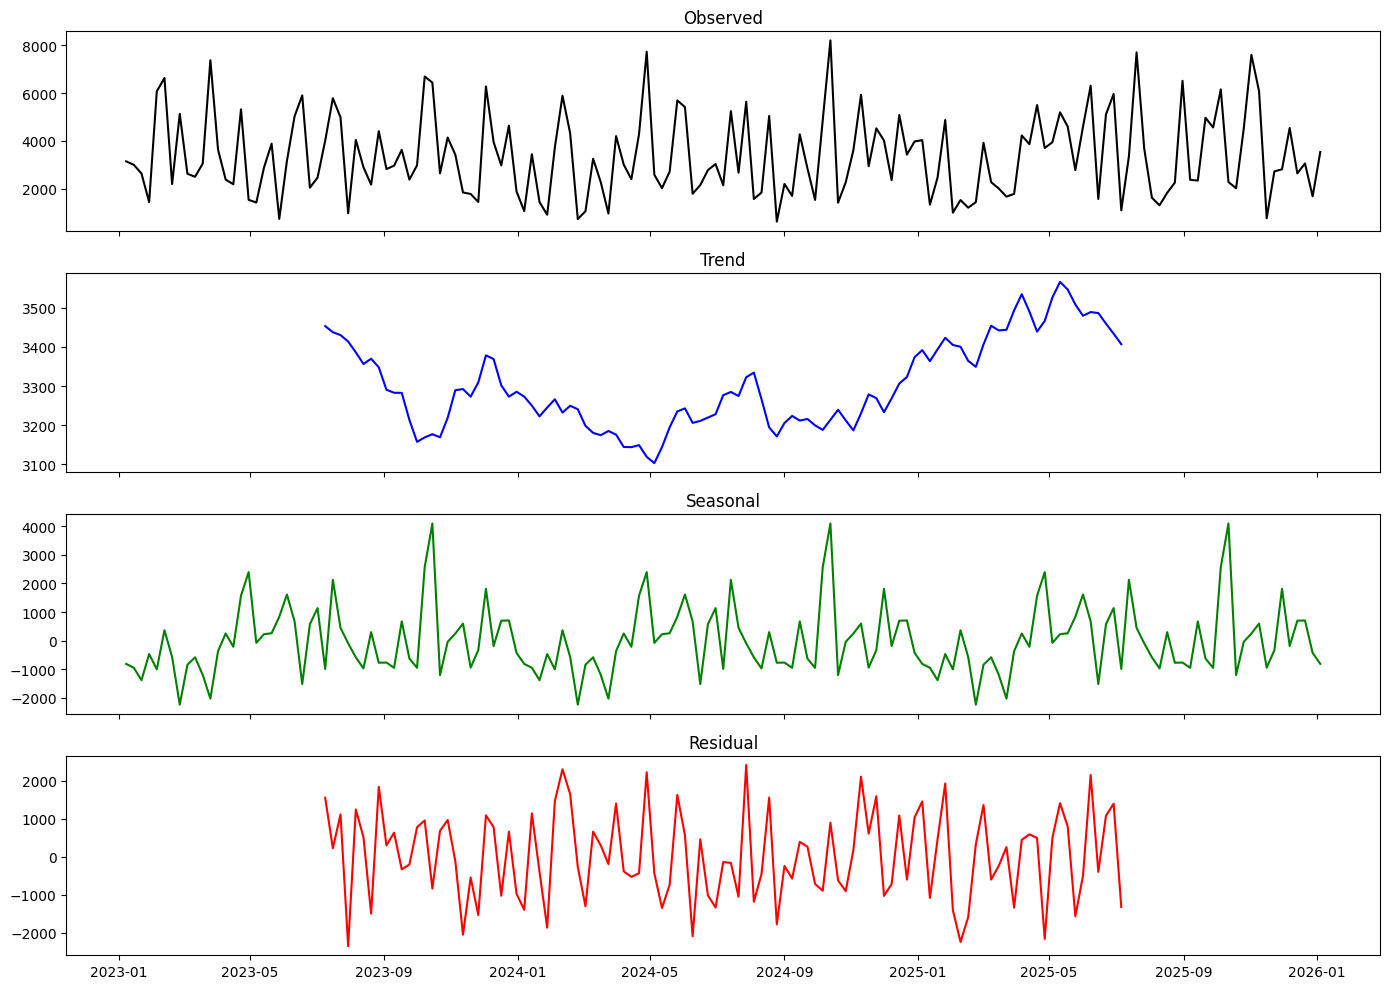

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomp.observed, color='black')
axes[0].set_title('Observed')

axes[1].plot(decomp.trend, color='blue')
axes[1].set_title('Trend')

axes[2].plot(decomp.seasonal, color='green')
axes[2].set_title('Seasonal')

axes[3].plot(decomp.resid, color='red')
axes[3].set_title('Residual')

plt.tight_layout()
plt.show()

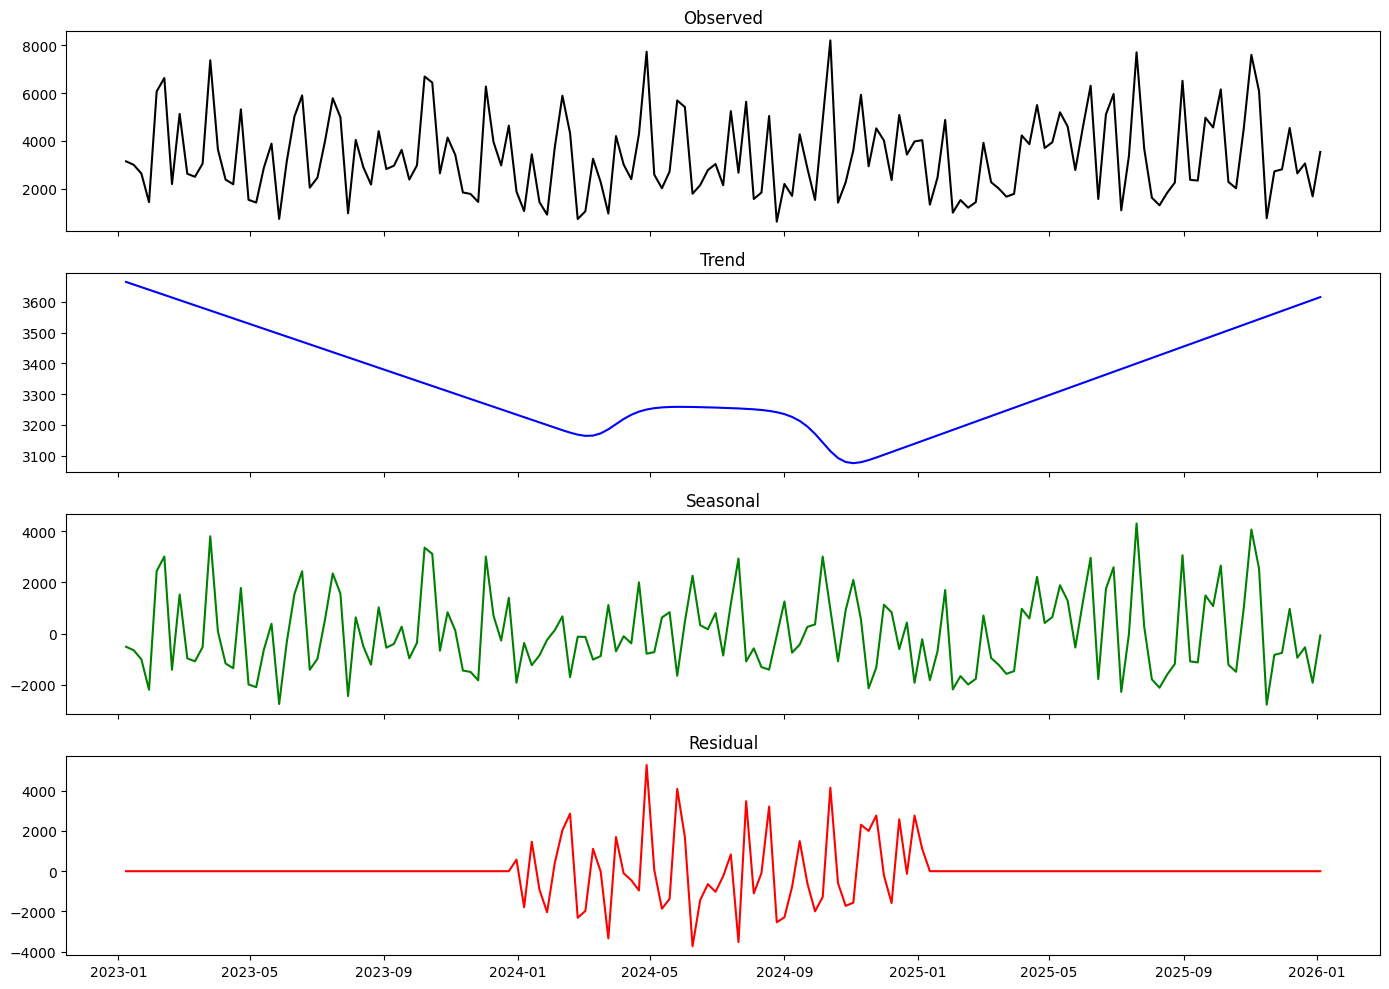

In [4]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

stl = STL(weekly, period=52, robust=True)
stl_res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(stl_res.observed, color='black')
axes[0].set_title('Observed')

axes[1].plot(stl_res.trend, color='blue')
axes[1].set_title('Trend')

axes[2].plot(stl_res.seasonal, color='green')
axes[2].set_title('Seasonal')

axes[3].plot(stl_res.resid, color='red')
axes[3].set_title('Residual')

plt.tight_layout()
plt.show()

In [7]:
residuals = stl_res.resid

rolling_mean = residuals.rolling(window=4, min_periods=1).mean()
rolling_std = residuals.rolling(window=4, min_periods=1).std()

upper_bound = rolling_mean + 2.5 * rolling_std
lower_bound = rolling_mean - 2.5 * rolling_std

anomalies_mask = (residuals > upper_bound) | (residuals < lower_bound)

expected_revenue = stl_res.trend + stl_res.seasonal

anomaly_table = pd.DataFrame({
    'Actual_Revenue': stl_res.observed,
    'Expected_Revenue': expected_revenue,
    'Residual': residuals,
    'Rolling_Mean': rolling_mean,
    'Rolling_Std': rolling_std
})


flagged_weeks = anomaly_table[anomalies_mask].copy()

print("=== FLAGGED ANOMALY WEEKS ===")
if not flagged_weeks.empty:
    print(flagged_weeks[['Actual_Revenue', 'Expected_Revenue']])
else:
    print("No anomalies detected outside the 2.5σ threshold with the current window.")

=== FLAGGED ANOMALY WEEKS ===
No anomalies detected outside the 2.5σ threshold with the current window.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


=== FORECAST EVALUATION METRICS ===
RMSE: 1934.78
MAPE: 68.06%


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

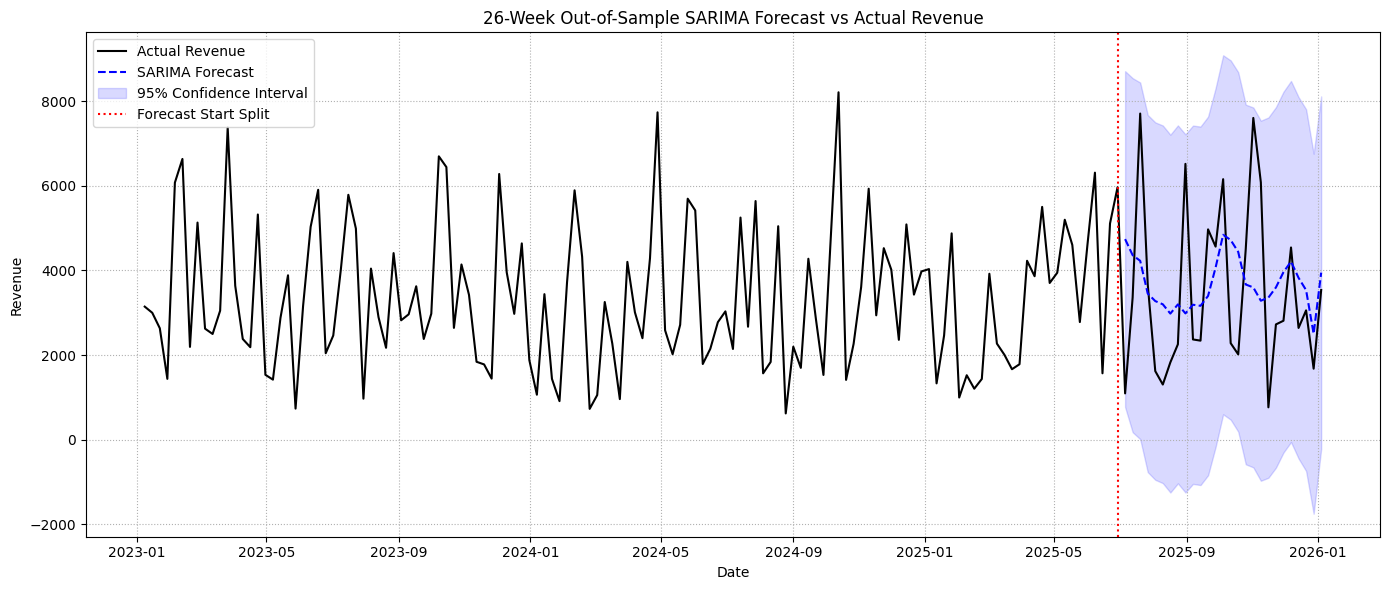

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

train_size = 130
train = weekly.iloc[:train_size]
test = weekly.iloc[train_size:]

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)

forecast_steps = len(test)
forecast_res = model_fit.get_forecast(steps=forecast_steps)

forecast_means = forecast_res.predicted_mean
confidence_intervals = forecast_res.conf_int(alpha=0.05)

forecast_means.index = test.index
confidence_intervals.index = test.index

actuals = test.values
predictions = forecast_means.values

rmse = np.sqrt(mean_squared_error(actuals, predictions))

mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print("=== FORECAST EVALUATION METRICS ===")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(14, 6))

plt.plot(weekly.index, weekly, label='Actual Revenue', color='black', linewidth=1.5)

plt.plot(forecast_means.index, forecast_means, label='SARIMA Forecast', color='blue', linestyle='--')

plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color='blue', alpha=0.15, label='95% Confidence Interval'
)

plt.axvline(x=train.index[-1], color='red', linestyle=':', label='Forecast Start Split')

plt.title('26-Week Out-of-Sample SARIMA Forecast vs Actual Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt